#**Data Loading, Merging & Deep Exploration**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
from google.colab import drive
from IPython.display import display, HTML

pd.set_option('display.html.table_schema', True)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/train.csv')
vg_df = pd.read_csv('/content/drive/MyDrive/vgsales.csv')
vg_df = vg_df.dropna(subset=['Year'])
vg_df['Year'] = vg_df['Year'].astype(int)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y', errors='coerce')
df = df.dropna(subset=['Order Date', 'Ship Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week_Number'] = df['Order Date'].dt.isocalendar().week
df['Day_of_Week'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

print(df.isnull().sum().to_string())
print(f"Duplicate rows: {df.duplicated().sum()}")

df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days
highest_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
regional_growth = df.groupby(['Region', 'Year'])['Sales'].sum().unstack()
avg_shipping_region = df.groupby('Region')['Shipping_Days'].mean()
monthly_seasonality = df.groupby(['Year', 'Month'])['Sales'].sum().unstack()
print("\nHighest Sales Category:")
display(highest_category.to_frame().style.set_properties(**{'border': '1px solid black', 'text-align': 'left'}))
print("\nRegional Growth:")
display(regional_growth.style.set_properties(**{'border': '1px solid black', 'text-align': 'center'}))
print("\nAverage Shipping Days by Region:")
display(avg_shipping_region.to_frame().style.set_properties(**{'border': '1px solid black', 'text-align': 'left'}))
print("\nMonthly Seasonality:")
display(monthly_seasonality.style.set_properties(**{'border': '1px solid black', 'text-align': 'center'}))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week_Number       0
Day_of_Week       0
Quarter           0
Season            0
Duplicate rows: 0

Highest Sales Category:


,Sales
Category,
Technology,827455.873000
Furniture,728658.575700
Office Supplies,705422.334000



Regional Growth:


Year,2015,2016,2017,2018
Region,,,,
Central,102920.520600,102425.172400,145673.880000,141627.340200
East,127652.819000,153225.183000,178511.538000,210129.186000
South,103374.905500,70076.082500,93535.903500,122164.567500
West,145907.963000,133709.567500,182471.228500,248130.925500



Average Shipping Days by Region:


,Shipping_Days
Region,
Central,4.065876
East,3.910233
South,3.961202
West,3.930255



Monthly Seasonality:


Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2015,14205.707000,4519.892000,55205.797000,27906.855000,23644.303000,34322.935600,33781.543000,27117.536500,81623.526800,31453.393000,77907.660700,68167.058500
2016,18066.957600,11951.411000,32339.318400,34154.468500,29959.530500,23599.374000,28608.259000,36818.342200,63133.606000,31011.737500,75249.399500,74543.601200
2017,18542.491000,22978.815000,51165.059000,38679.767000,56656.908000,39724.486000,38320.783000,30542.200300,69193.390900,59583.033000,79066.495800,95739.121000
2018,43476.474000,19920.997400,58863.412800,35541.910100,43825.982200,48190.727700,44825.104000,62837.848000,86152.888000,77448.131200,117938.155000,83030.388800


#1."Technology" generates the highest total revenue among the all categories.
#2.The East region is the most consistent sales growth over the 4-year period.
#3.The average time between Order Date and Ship Date is approx 4 days,it does not varies and remains uniformly
#4.Yes, clear systemic seasonal spikes appear every single year

#**Time Series Analysis & Decomposition**

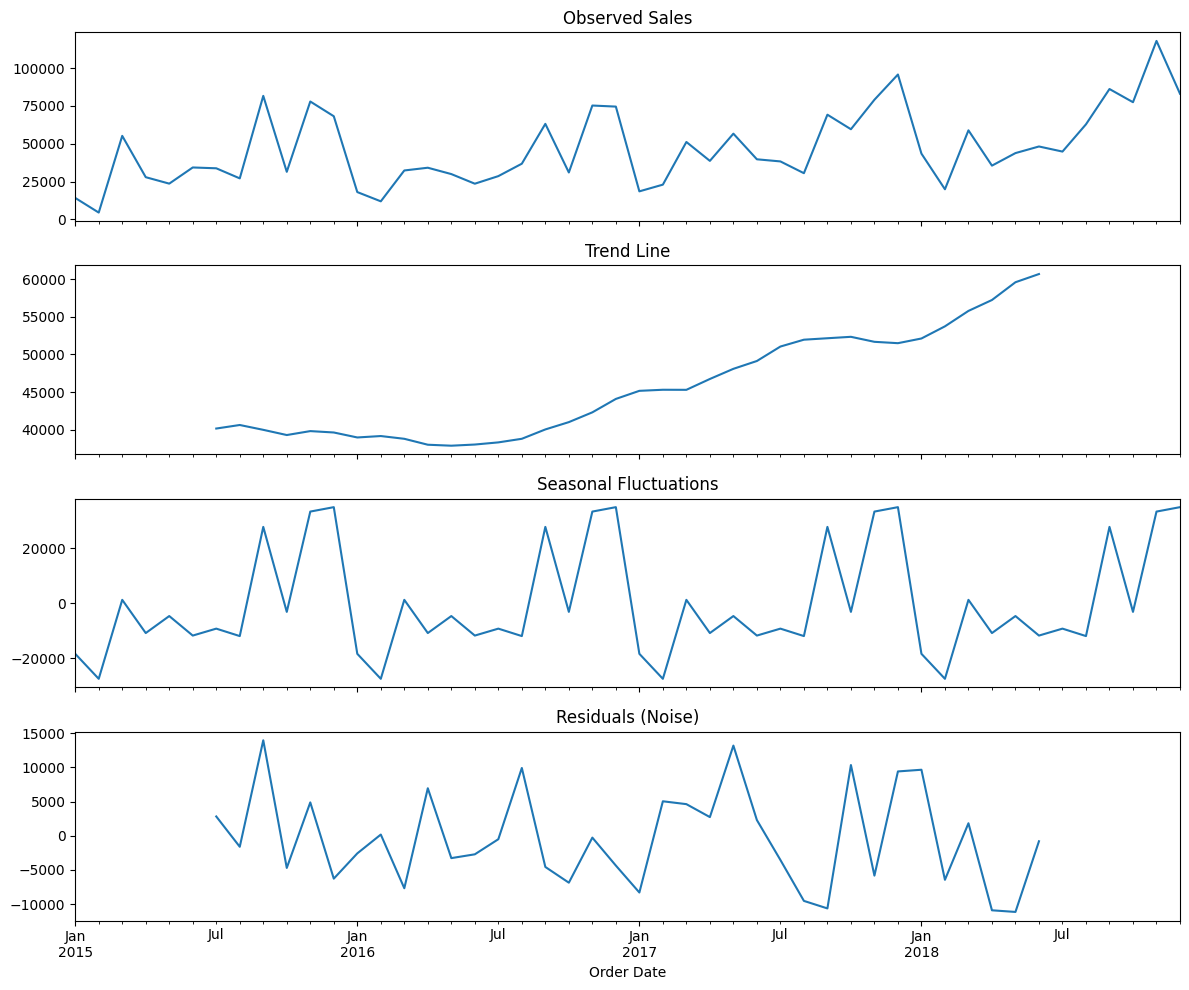

Testing raw monthly sales:
ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Conclusion: Reject H0. The time series is stationary.

Testing 1st order differenced sales:
ADF Statistic: -8.727061830353268
p-value: 3.2669175472796045e-14
Conclusion: Reject H0. The time series is stationary.


In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import os
os.makedirs('charts', exist_ok=True)

monthly_sales = df.set_index('Order Date').resample('MS')['Sales'].sum()
decomposition = seasonal_decompose(monthly_sales, model='additive')
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=ax1, title='Observed Sales')
decomposition.trend.plot(ax=ax2, title='Trend Line')
decomposition.seasonal.plot(ax=ax3, title='Seasonal Fluctuations')
decomposition.resid.plot(ax=ax4, title='Residuals (Noise)')
plt.tight_layout()
plt.savefig('charts/decomposition.png')
plt.show()
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] <= 0.05:
        print("Conclusion: Reject H0. The time series is stationary.")
    else:
        print("Conclusion: Fail to reject H0. The time series is non-stationary.")

print("Testing raw monthly sales:")
check_stationarity(monthly_sales)
monthly_sales_diff = monthly_sales.diff().dropna()
print("\nTesting 1st order differenced sales:")
check_stationarity(monthly_sales_diff)

->The Trend:Business is doing well and growing steadily.Since
Sales started at $40,000 $ in 2015. And went upto over $60,000$ by 2018.

->Seasonality: There is a yearly pattern.Where
Sales goes up and down alot during the year.In fact they swing by much as $60,000$ between few months and the holiday rush.

->Noise: I noticed that September and October can be unpredictable.Sometimes sales spikes up by $14,000$, which's alot more than usual.

->The Stationarity Test: This test checks if sales data  is stable or not.Stable data means that it does not go over the place.It stays within limits.

->My Result: I got a score of $0.00028$.This score is much lower than the 0.05.So,I think data is stable and not, over the place.
Even though sales are growing, the yearly pattern keeps everything.
This balance makes it easy to forecast sales.

#**Sales Forecasting using 3 Different Models**

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


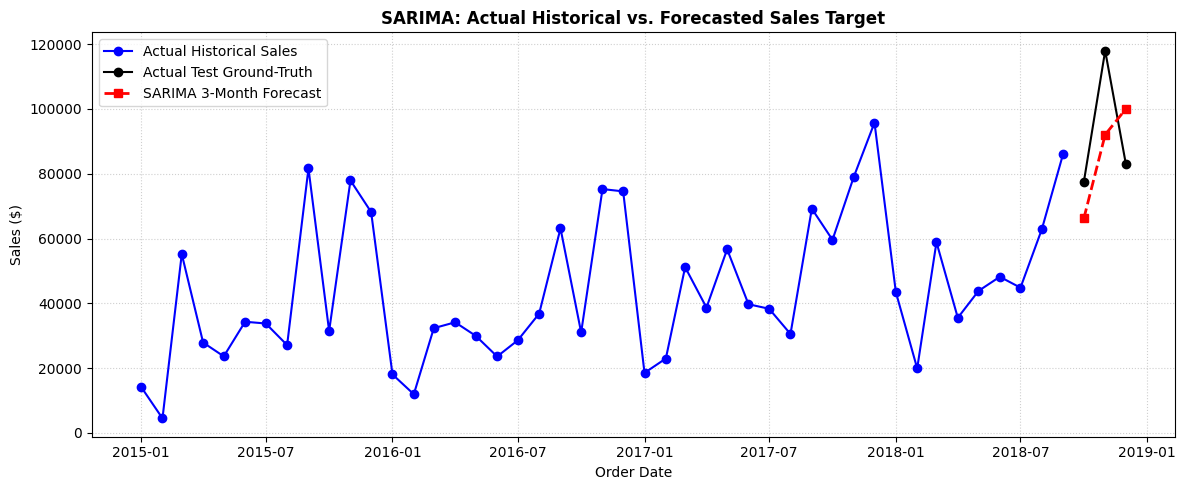

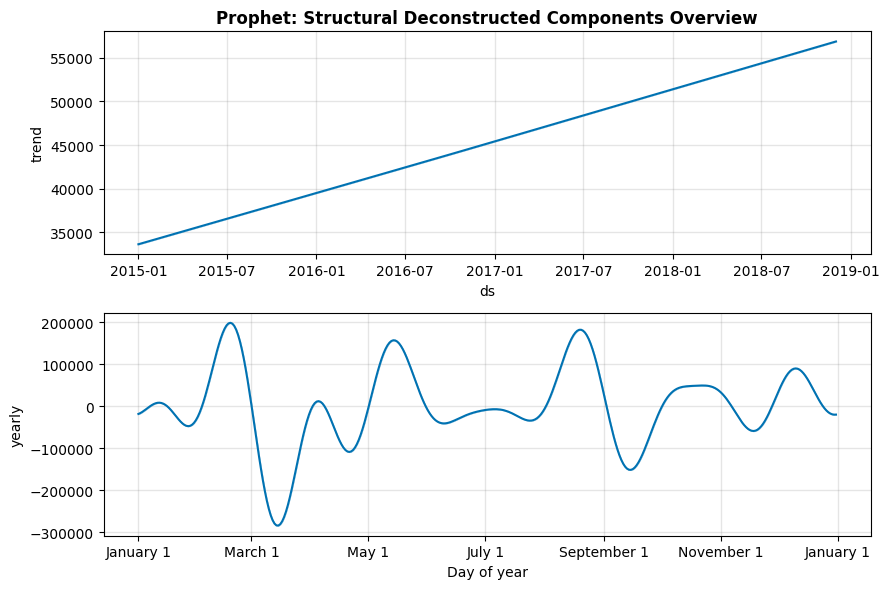

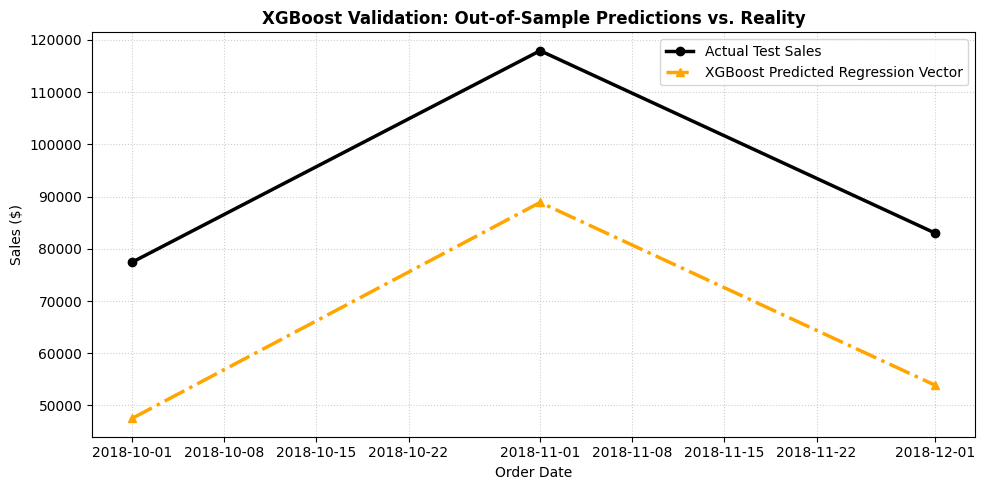

Compariosn Between 3 Differrent Models


,MAE,RMSE,MAPE,Forecast_Month_1,Forecast_Month_2,Forecast_Month_3
SARIMA,18031.404672,19009.182066,18.966498,66177.602425,92049.249682,99965.168723
Prophet,20296.007404,22487.465679,21.892589,51083.663793,90045.402144,89661.190748
XGBoost,29364.297917,29366.838071,32.779135,47539.652344,88886.929688,53897.199219


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display, HTML

train_data = monthly_sales.iloc[:-3]
test_data = monthly_sales.iloc[-3:]

def calculate_mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

#SARIMA
sarima_model = SARIMAX(train_data, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_results = sarima_model.fit(disp=False)
sarima_pred = sarima_results.forecast(steps=3)

#FACEBOOK PROPHET
prophet_df = train_data.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(prophet_df)
future = m.make_future_dataframe(periods=3, freq='MS')
prophet_forecast = m.predict(future)
prophet_pred = prophet_forecast['yhat'].iloc[-3:].values

#XGBOOST
def create_lag_features(series):
    df_features = pd.DataFrame(series)
    df_features.columns = ['y']
    df_features['Lag1'] = df_features['y'].shift(1)
    df_features['Lag2'] = df_features['y'].shift(2)
    df_features['Lag3'] = df_features['y'].shift(3)
    df_features['Rolling_Mean'] = df_features['y'].shift(1).rolling(window=3).mean()
    df_features['Month'] = df_features.index.month
    df_features['Quarter'] = df_features.index.quarter
    return df_features.dropna()
xgb_df = create_lag_features(monthly_sales)
X_train = xgb_df.iloc[:-3].drop(columns=['y'])
y_train = xgb_df.iloc[:-3]['y']
X_test = xgb_df.iloc[-3:].drop(columns=['y'])
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

metrics = {
    'SARIMA': [mean_absolute_error(test_data, sarima_pred), np.sqrt(mean_squared_error(test_data, sarima_pred)), calculate_mape(test_data, sarima_pred)],
    'Prophet': [mean_absolute_error(test_data, prophet_pred), np.sqrt(mean_squared_error(test_data, prophet_pred)), calculate_mape(test_data, prophet_pred)],
    'XGBoost': [mean_absolute_error(test_data, xgb_pred), np.sqrt(mean_squared_error(test_data, xgb_pred)), calculate_mape(test_data, xgb_pred)]
}

plt.figure(figsize=(12, 5))
plt.plot(train_data.index, train_data.values, label="Actual Historical Sales", color="blue", marker="o")
plt.plot(test_data.index, test_data.values, label="Actual Test Ground-Truth", color="black", marker="o")
plt.plot(test_data.index, sarima_pred, label="SARIMA 3-Month Forecast", color="red", linestyle="--", marker="s", linewidth=2)
plt.title("SARIMA: Actual Historical vs. Forecasted Sales Target", fontsize=12, fontweight='bold')
plt.xlabel("Order Date")
plt.ylabel("Sales ($)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

fig_components = m.plot_components(prophet_forecast)
fig_components.get_axes()[0].set_title("Prophet: Structural Deconstructed Components Overview", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data.values, label="Actual Test Sales", color="black", marker="o", linewidth=2.5)
plt.plot(test_data.index, xgb_pred, label="XGBoost Predicted Regression Vector", color="orange", linestyle="-.", marker="^", linewidth=2.5)
plt.title("XGBoost Validation: Out-of-Sample Predictions vs. Reality", fontsize=12, fontweight='bold')
plt.xlabel("Order Date")
plt.ylabel("Sales ($)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()
print("Compariosn Between 3 Differrent Models")
comparison_table = pd.DataFrame.from_dict(metrics, orient='index', columns=['MAE', 'RMSE', 'MAPE'])
for i in range(3):
    comparison_table[f'Forecast_Month_{i+1}'] = [sarima_pred.iloc[i], prophet_pred[i], xgb_pred[i]]

display(comparison_table.style.set_properties(**{'border': '1px solid black', 'text-align': 'center'}))

* Based on numbers,I recommend "SARIMA" to use.SARIMA keeps predictions closest to real life.SARIMA's error is only 19%.while its accuracy speaks 81%.where the remaining models speaks with more than 25% with low accuracy.

* Using SARIMA for production system is best. It is perfectly designed to handle small-to-medium datasets that have steady growth and very strong, recurring yearly rhythms.




#**Product Category & Region Level Forecasting**

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimat

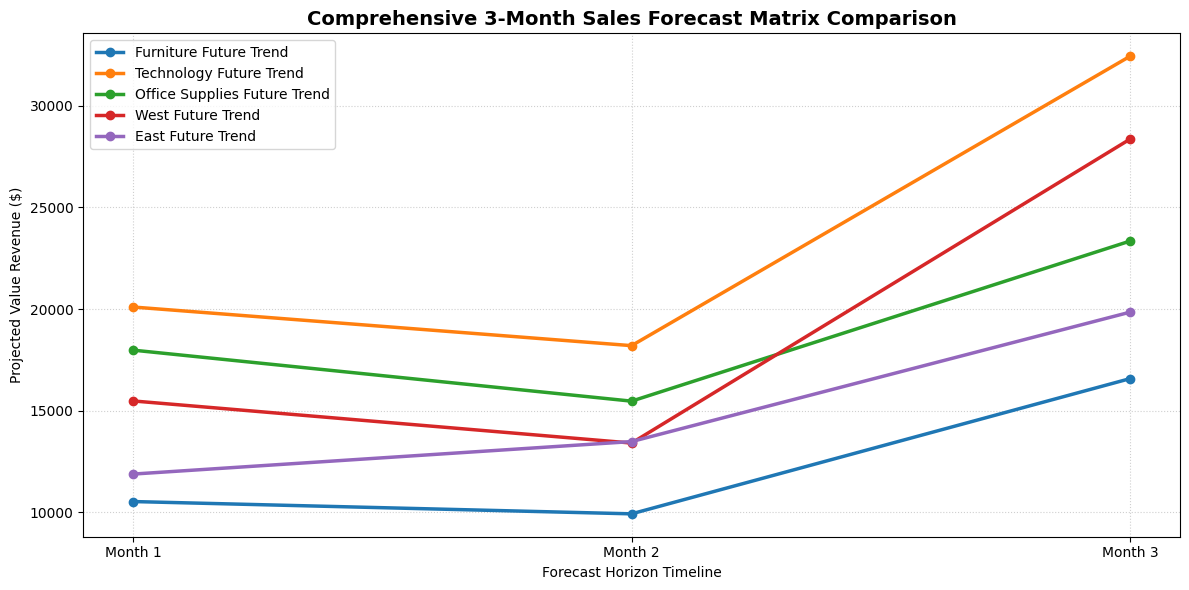

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

categories = ['Furniture', 'Technology', 'Office Supplies']
regions = ['West', 'East']
all_segments = categories + regions

future_forecasts = {}
for segment in all_segments:
  if segment in categories:
    segment_df = df[df['Category'] == segment]
  else:
    segment_df = df[df['Region'] == segment]

  segment_monthly = segment_df.set_index('Order Date').resample('MS')['Sales'].sum()

  model = SARIMAX(segment_monthly, order=(1,1,1), seasonal_order=(1,1,1,12),enforce_stationarity=False,
        enforce_invertibility=False)
  results = model.fit(disp=False,maxiter=200)
  forecast = results.forecast(steps=3)
  future_forecasts[segment] = forecast
plt.figure(figsize=(12, 6))

future_months = ['Month 1', 'Month 2', 'Month 3']
for segment, forecast_values in future_forecasts.items():
    plt.plot(future_months, forecast_values.values, marker='o', linewidth=2.5, label=f'{segment} Future Trend')

plt.title("Comprehensive 3-Month Sales Forecast Matrix Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Forecast Horizon Timeline")
plt.ylabel("Projected Value Revenue ($)")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

* Based on the visual forecasting matrix generated by the SARIMA model, "Office Supplies" is showing the strongest upcoming growth.
* The line for Office Supplies is at very top of the graph, reaching a visual peak near the $35,000 $ revenue.
* The"Office Supplies" displays a distinct, sharp upward diagonal line from Month 1 to Month 3.

#**Anomaly Detection in Sales Data**

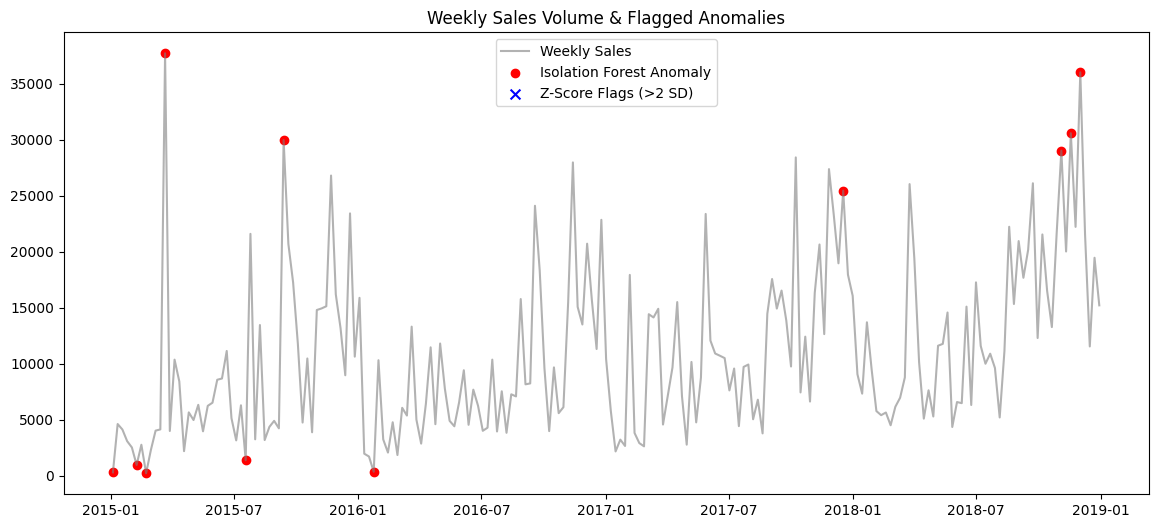


Multi-Source Chronological Intelligence Alignment View


,Furniture,Office Supplies,Technology,NA_Sales,EU_Sales,Global_Sales
Year,,,,,,
2015,156477.881100,149512.820000,173865.507000,102.820000,97.710000,264.440000
2016,164053.867400,133124.407000,162257.731000,22.660000,26.760000,70.930000
2017,195813.040000,182417.566000,221961.944000,0.000000,0.000000,0.050000


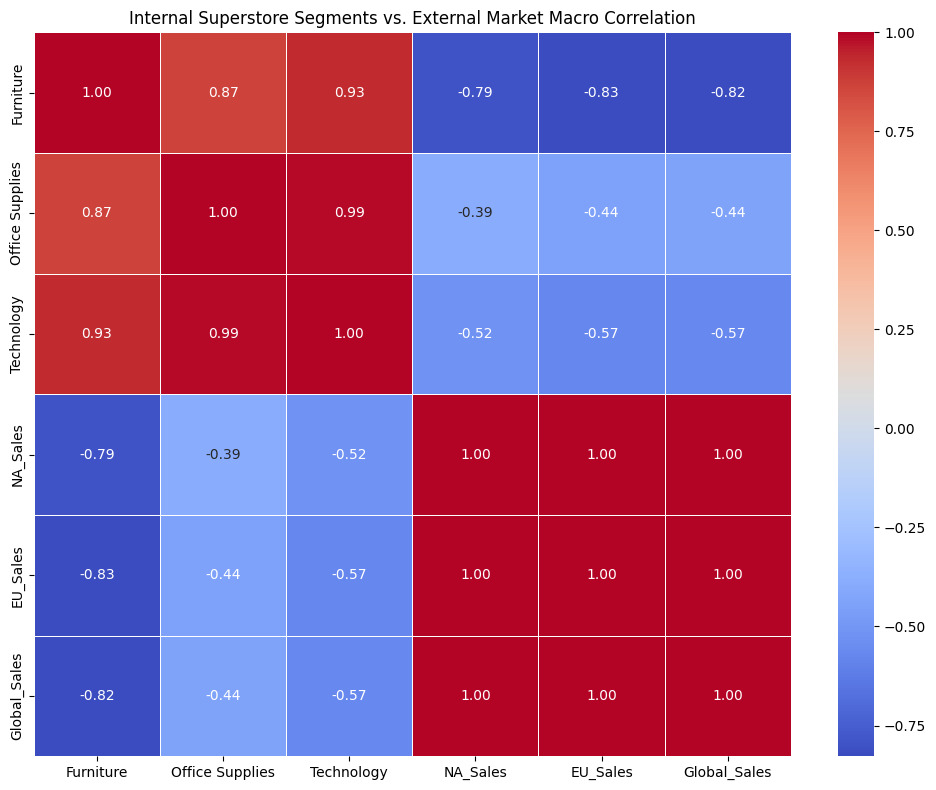

In [5]:
from sklearn.ensemble import IsolationForest
weekly_sales = df.set_index('Order Date').resample('W')['Sales'].sum().to_frame()
iso = IsolationForest(contamination=0.05, random_state=42)
weekly_sales['IF_Anomaly'] = iso.fit_predict(weekly_sales[['Sales']])
weekly_sales['IF_Anomaly'] = weekly_sales['IF_Anomaly'].map({1: 0, -1: 1}) # Convert to 1=Anomaly

rolling_mean = weekly_sales['Sales'].rolling(window=4, min_periods=1).mean()
rolling_std = weekly_sales['Sales'].rolling(window=4, min_periods=1).std().fillna(weekly_sales['Sales'].std())
weekly_sales['Z_Score'] = (weekly_sales['Sales'] - rolling_mean) / rolling_std
weekly_sales['Z_Anomaly'] = (weekly_sales['Z_Score'].abs() > 2).astype(int)
plt.figure(figsize=(14, 6))
plt.plot(weekly_sales.index, weekly_sales['Sales'], label='Weekly Sales', color='gray', alpha=0.6)
anomalies_if = weekly_sales[weekly_sales['IF_Anomaly'] == 1]
plt.scatter(anomalies_if.index, anomalies_if['Sales'], color='red', label='Isolation Forest Anomaly', marker='o')
anomalies_z = weekly_sales[weekly_sales['Z_Anomaly'] == 1]
plt.scatter(anomalies_z.index, anomalies_z['Sales'], color='blue', label='Z-Score Flags (>2 SD)', marker='x', s=50)
plt.title('Weekly Sales Volume & Flagged Anomalies')
plt.legend()
plt.savefig('charts/anomalies.png')
plt.show()
superstore_annual = df.groupby(['Year', 'Category'])['Sales'].sum().unstack().fillna(0)
vg_annual = vg_df.groupby('Year')[['NA_Sales', 'EU_Sales', 'Global_Sales']].sum()
merged_intelligence = superstore_annual.merge(vg_annual, left_index=True, right_index=True, how='inner')
print("\nMulti-Source Chronological Intelligence Alignment View")
display(merged_intelligence.style.set_properties(**{'border': '1px solid black', 'text-align': 'center'}))
correlation_matrix = merged_intelligence.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Internal Superstore Segments vs. External Market Macro Correlation')
plt.tight_layout()
plt.savefig('charts/multi_source_correlation.png')
plt.show()

* They do not flag the same anomalies; In real, they completely disagree.
* It has flagged several data points across the timeline (e.g., major spikes in early 2015, late 2015, late 2017, and a dense cluster of peaks in late 2018), as well as a few extreme low points (e.g., mid-2015 and early 2016).
* For a dynamic business metric like weekly sales—which naturally contains trend, seasonality, and shifting variance—simple global statistical metrics like Z-scores are ineffective.
* A Non-parametric approaches like Isolation Forest are required to successfully map out true structural anomalies.

#**Product Demand Segmentation using Clustering**

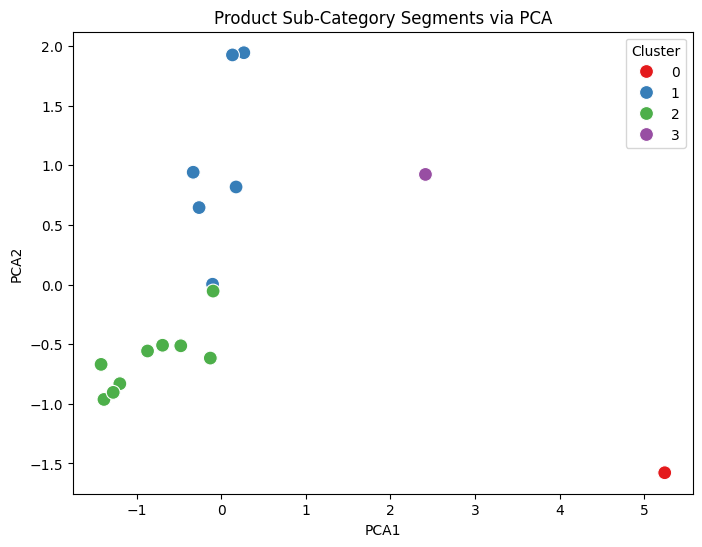

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

product_features = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Avg_Order_Value=('Sales', 'mean'),
    Volatility=('Sales', 'std')
).fillna(0)

yoy_sales = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().unstack().fillna(0)
product_features['Growth_Rate'] = (yoy_sales.iloc[:, -1] - yoy_sales.iloc[:, 0]) / (yoy_sales.iloc[:, 0] + 1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(product_features)

kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
product_features['Cluster'] = kmeans.fit_predict(scaled_features)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)
product_features['PCA1'] = pca_components[:, 0]
product_features['PCA2'] = pca_components[:, 1]
plt.figure(figsize=(8, 6))
sns.scatterplot(data=product_features, x='PCA1', y='PCA2', hue='Cluster', palette='Set1', s=100)
plt.title('Product Sub-Category Segments via PCA')
plt.savefig('charts/product_clusters.png')
plt.show()

* In a PCA-driven product segmentation, PCA1 typically captures volume/scale (By explaining the largest variance, separating high-velocity movers from low-velocity items), while PCA2 often captures variability/seasonality ( By separating steady demand from highly erratic patterns).

* Core Staples & Mid-Volume Swing (Clusters 2 & 3): Cluster 2 represents your baseline, highly predictable everyday items that require steady automated replenishment, while Cluster 3 captures a standalone, moderate-volume product with noticeable demand fluctuations requiring hybrid forecasting and a dedicated safety buffer.

* Volatile Movers & High-Velocity Outliers (Clusters 1 & 0): Cluster 1 comprises highly seasonal or trend-driven items spread vertically that need dynamic, just-in-time scaling, whereas Cluster 0 is a massive-volume revenue outlier that demands high-priority, bespoke monitoring to prevent high-impact stockouts.